#**PROCESAMIENTO ELECTROCARDIOGRAMA 12 DERIVACIONES**#

Análisis de señales electrocardiográficas obtenidas en un protocolo tradicional de 12 derivaciones

**Formtato de archivo de datos**: TIME STAMPS + 2 CANALES




## **ESTAPAS DE ANÁLISIS**

1.  **PROCESAMIENTO BÁSICO**: Acondicionamiento, espectro y filtrado
2.  **PROCESAMIENTO AVANZADO**: Puntos Característicos ECG y Frecuencia Cardíaca

## **MÓDULOS DE USO GENERAL**

In [1]:
import numpy as np              #Módulo Numérico General
import scipy as sp              #Módulo Procesamiento de Señales
import math as mt               #Módulo Matemático
import matplotlib.pyplot as plt #Visualización

## **CARGA DE SEÑALES ADQUIRIDAS**

In [2]:
#IMPORTACIÖN DE ARCHIVO DE DATOS A COLAB
from google.colab import files
uploaded=files.upload()

Saving MIT_RSIN_16786.txt to MIT_RSIN_16786.txt


In [3]:
#LECTURA DE LOS PARÁMETROS MEDIDOS (FORMATO MIT)
filename=next(iter(uploaded))
#DATOS=np.loadtxt(filename,delimiter=" ", dtype=str,skiprows=2)
DATOS=np.loadtxt(filename,dtype=str,skiprows=2)

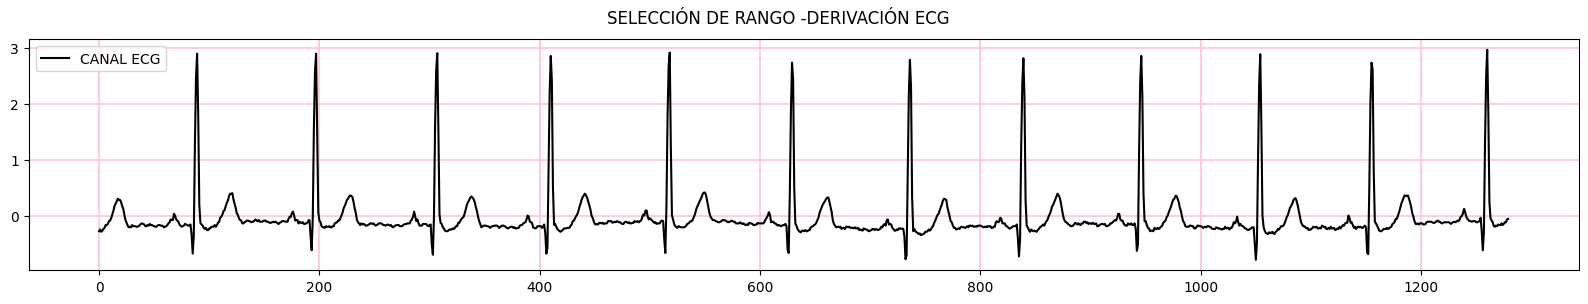

In [4]:
#SELECCIÓN DE RANGO DE TRABAJO
#Separación de tipos de datos
ECG_CH=(np.array(DATOS[:,1]).astype('float'))
N=len(ECG_CH)
#Visualización para selección de rango
plt.figure(figsize=[20,3])
plt.plot(ECG_CH,'k',label='CANAL ECG')
plt.suptitle('SELECCIÓN DE RANGO -DERIVACIÓN ECG')
plt.grid(True, axis='both', linestyle='-', zorder=0, linewidth=1.1 , color = 'pink')
plt.legend()

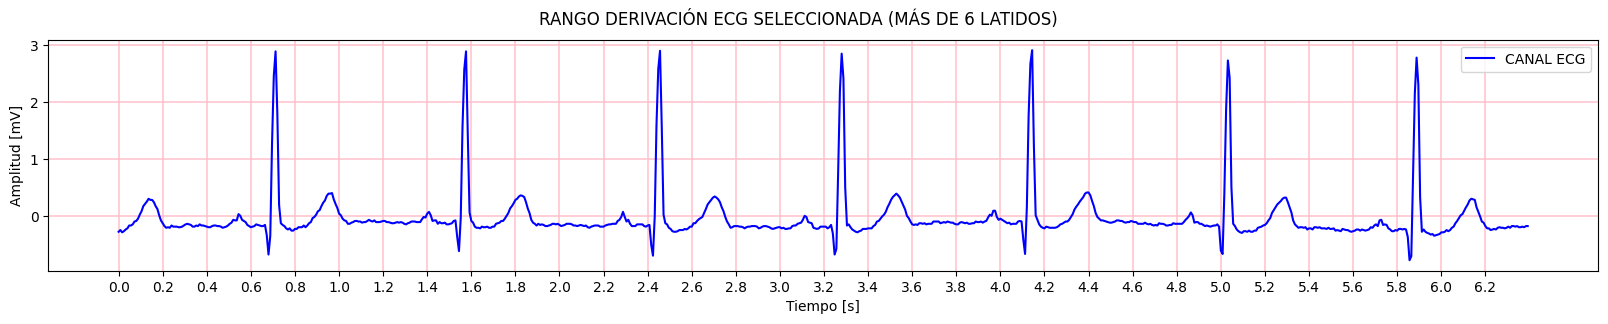

In [5]:
#DETERMINACIÓN DEL RANGO DE ANÁLISIS
N=800                 #VENTANA DE EVALUACIÖN
RANGO_INI=0           #INICIO RANGO
RANGO_FIN=RANGO_INI+N #FIN RANGO

#Vector Temporal
Fs=125 #Hz
Ts=1/Fs
t=np.arange(0,N*Ts,Ts)

#Armado de la grilla ECG Profesional
step_40 = 0.2     #CUADRADO ECG GRANDE 200ms
step_200 = 0.040  #CUADRADO ECG CHICO  40ms
ct_pos_200 = np.arange(0, t[-1], step_40)    # Usada por grilla principal cada 200 mSeg

#ASIGNACIÓN DE RANGO
ECG_CH=ECG_CH[RANGO_INI:RANGO_FIN]

#VISUALIZCIÓN
fig,ax=plt.subplots(1, 1, figsize=(20, 3))
plt.plot(t,ECG_CH,'b',label='CANAL ECG')
plt.suptitle('RANGO DERIVACIÓN ECG SELECCIONADA (MÁS DE 6 LATIDOS)')
ax.set_xticks(ct_pos_200)
plt.grid(True, axis='both', linestyle='-', zorder=0, linewidth=1.1 , color = 'pink')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [mV]')
plt.legend()

## **PROCESAMIENTO INICIAL**

### **1. ACONDICIONAMIENTO Y ANÁLISIS ESPECTRAL**

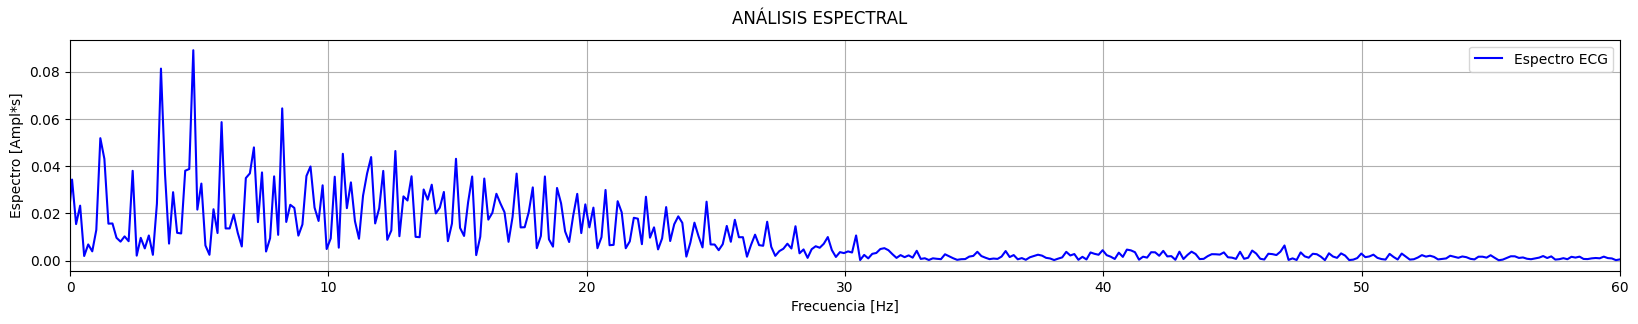

In [6]:
#1.ANÁLISIS ESPECTRAL
N_fft=len(ECG_CH)
X_f_ECG=sp.fft.fftshift(sp.fft.fft(ECG_CH))/N_fft
f=np.linspace(-Fs/2,Fs/2,N_fft)

#VISUALIZACIÓN
plt.figure(figsize=(20,3))
plt.plot(f, np.abs(X_f_ECG),'b',label='Espectro ECG')
plt.xlim([0,60])
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Espectro [Ampl*s]')
plt.suptitle('ANÁLISIS ESPECTRAL')
plt.legend()
plt.grid()

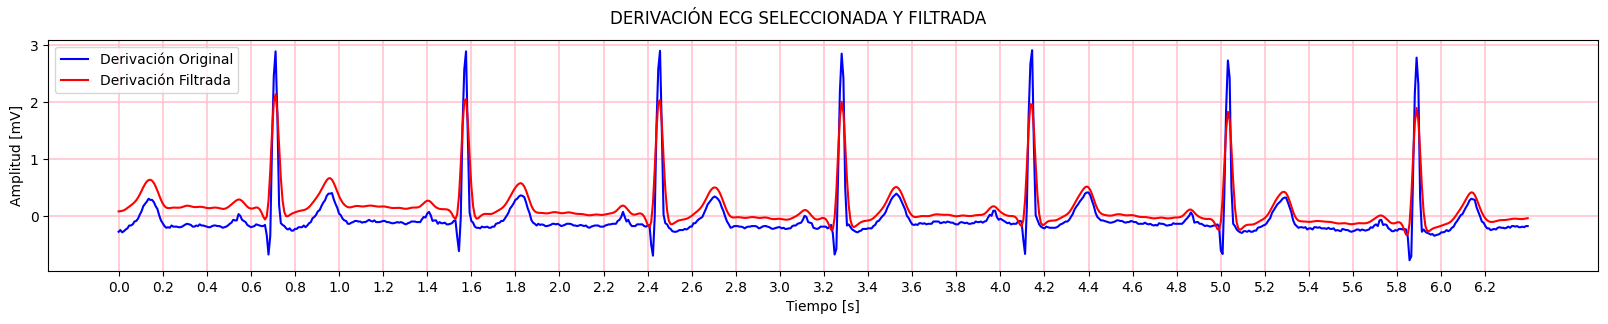

In [7]:
#2.FILTRADO DIGITAL
#Coeficientes b (x, NUMERADOR H=Y/X)
#Coeficientes a (y, DENOMINADOR H=Y/X)

#Filtro Pasabanda Butterworth a ECG (IIR)
FCI=0.05 #Hz Elimina respiracón para lograr linea de base estable
FCS=15 #Hz Elimina ruido
FCI_N=FCI/(0.5*Fs)
FCS_N=FCS/(0.5*Fs)
b, a=sp.signal.butter(2,[FCI_N,FCS_N],btype='bandpass')
#Aplicación del filtro
ECG_CH_f=sp.signal.filtfilt(b, a, ECG_CH)
#NOTA: Se aplica filtfilt en lugar de lfilt para EVITAR que la señal filtrada quede DESFASADA de la original

#VISUALIZACIÓN
fig,ax=plt.subplots(1, 1, figsize=(20, 3))
plt.plot(t,ECG_CH,'b',label='Derivación Original')
plt.plot(t,ECG_CH_f,'r',label='Derivación Filtrada')
plt.suptitle('DERIVACIÓN ECG SELECCIONADA Y FILTRADA')
ax.set_xticks(ct_pos_200)
plt.grid(True, axis='both', linestyle='-', zorder=0, linewidth=1.1 , color = 'pink')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [mV]')
plt.legend()

## **PROCESAMIENTO AVANZADO**

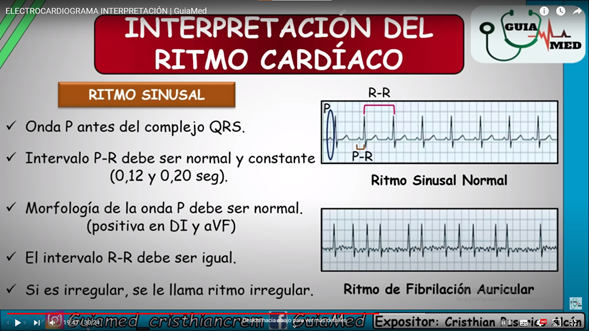

### **1. PUNTOS CARACTERÍSTICOS**

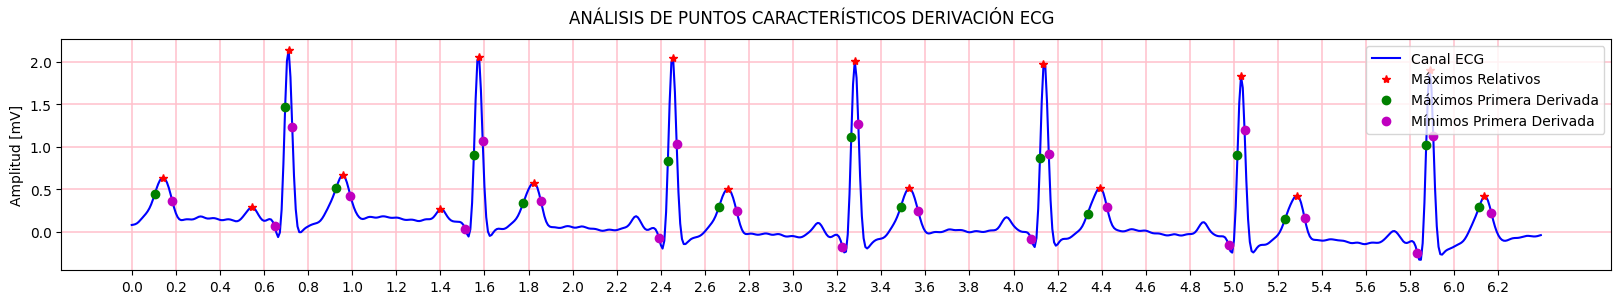

In [8]:
#PUNTOS DE INTERÉS
#INTERVALO P-R (Inicio de la onda P hasta Pico RR)
#ONDA P
#DISPERSIÓN DEL RR

#Obtención de las Derivadas (Detección de Puntos Característicos)
ECG_Der_1=np.gradient(ECG_CH_f)/Ts
ECG_Der_2=np.gradient(ECG_Der_1)/Ts
ECG_Max_Rel_Pos, _=sp.signal.find_peaks(ECG_CH_f, height=0.2)
ECG_Der_1_Max_Pos, _=sp.signal.find_peaks(ECG_Der_1, height=5)
ECG_Der_1_Min_Pos, _=sp.signal.find_peaks(-ECG_Der_1, height=5)

#VISUALIZACIÓN
fig,ax=plt.subplots(1, 1, figsize=(20, 3))
plt.plot(t,ECG_CH_f,'b',label='Canal ECG')
plt.plot(t[ECG_Max_Rel_Pos],ECG_CH_f[ECG_Max_Rel_Pos],'r*',label='Máximos Relativos')
plt.plot(t[ECG_Der_1_Max_Pos],ECG_CH_f[ECG_Der_1_Max_Pos],'go',label='Máximos Primera Derivada')
plt.plot(t[ECG_Der_1_Min_Pos],ECG_CH_f[ECG_Der_1_Min_Pos],'mo',label='Mínimos Primera Derivada')
plt.ylabel('Amplitud [mV]')
plt.suptitle('ANÁLISIS DE PUNTOS CARACTERÍSTICOS DERIVACIÓN ECG')
ax.set_xticks(ct_pos_200)
plt.grid(True, axis='both', linestyle='-', zorder=0, linewidth=1.1 , color = 'pink')
plt.legend()

### **2. FRECUENCIA CARDÍACA**

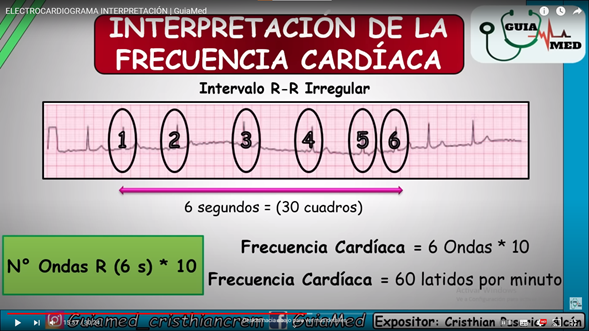

------------------------------------------------------------------------------
Latidos Detectados= 7
Frecuencia Cardíaca (media y dispersión): 69.6 ± 1.8 lpm
Frecuenca estimada según cantidad de latidos encontrados: 66 lpm
------------------------------------------------------------------------------


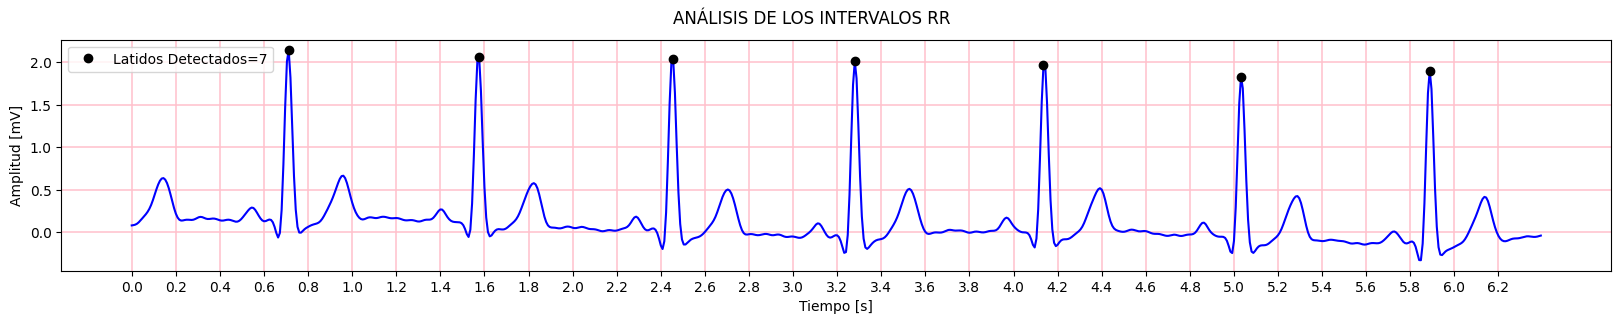

In [9]:
#Detección de Máximos con Umbral para separación por RR
ECG_RR_Pos, _=sp.signal.find_peaks(ECG_CH_f, height=1.5)

#Duración de Latidos
RR=np.diff(t[ECG_RR_Pos])
#Frecuencia Cardíaca (FC) latido a latido
FC=60/RR
#Estimación de FC según cantidad de latidos encontrados en el intervalo analizado
FC_Est=np.round(((len(RR)+1)/t[-1])*60)

#RESULTADOS
print('------------------------------------------------------------------------------')
print('Latidos Detectados= %d' %len(ECG_RR_Pos))
print('Frecuencia Cardíaca (media y dispersión): %.1f' %np.mean(FC),'± %.1f' %np.std(FC),'lpm')
print('Frecuenca estimada según cantidad de latidos encontrados: %d' %FC_Est,'lpm')
print('------------------------------------------------------------------------------')

#VISUALIZACIÓN
fig,ax=plt.subplots(1, 1, figsize=(20, 3))
plt.plot(t,ECG_CH_f,'b')
plt.plot(t[ECG_RR_Pos],ECG_CH_f[ECG_RR_Pos],'ko',label='Latidos Detectados='+str(len(ECG_RR_Pos)))
ax.set_xticks(ct_pos_200)
plt.grid(True, axis='both', linestyle='-', zorder=0, linewidth=1.1 , color = 'pink')
#plt.title=('DETECCIÓN DE LATIDOS')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [mV]')
plt.suptitle('ANÁLISIS DE LOS INTERVALOS RR')
plt.legend()

### **3. LATIDO PROMEDIO**

In [10]:
def FUN_PromLatidos(x, x_PosLat, t):
#--------------------------------------------------------------------------
#FUNCION:FUN_PromLat
#Cálculo de un latido promedio correspondiente a los latidos detectados de una serie.
#Los latidos se interpolan previamente a un un latido cuya duración es la mínima de las
#duraciones de todos los latidos, para evitar deformación por diferencia de duración.
#
#ENTRADA: x          -> Señal a analizar
#         x_PosLat   -> Ubicación de los latidos (se obtiene con FUN_DetLatidos)
#         t          -> Intervalo temporal
#SALIDA:  Lat_Prom   -> Latido promediado a la duración de latido mínima
#         t_prom     -> Vector temporal latido promedio
#
#EJEMPLO:
#    x_Latidos=FUN_DetCiclos(x, 90, 1)
#    x_PosLat = np.where(x_latidos)[0]
#    Lat_Prom,t_Prom=FUN_PromLatidos(xf_BT_ff, x_PosLat, t)
#
#MÓDULOS UTILIZADOS:
#    numpy (as np) y scipy (as sp)
#--------------------------------------------------------------------------
    #Intervalo de muestreo
    Ts = t[1] - t[0]
    #Vector Latido Promedio
    Lat_Prom = 0
    #Latido de duración mínima
    Lat_Long_min = min(np.diff(x_PosLat))
    for k in range(len(x_PosLat)-1):
        #Intervalo latido a interpolar (definido de 0 a 1)
        pini = x_PosLat[k]
        pfin = x_PosLat[k+1] - 1
        Lat_t_act=np.linspace(0,1,pfin-pini)
        #Intervalo latido interpolado (definido de 0 a 1)
        Lat_t_min=np.linspace(0,1,Lat_Long_min)
        #Interpolación latido
        Lat_int = np.interp(Lat_t_min, Lat_t_act, x[pini:pfin])
        #Suma de latido interpolado
        Lat_Prom += Lat_int
    #Promedio según la cantidad de latidos
    Lat_Prom /= len(x_PosLat) - 1
    t_Prom=np.arange(0,Lat_Long_min*Ts,Ts)
    return Lat_Prom, t_Prom

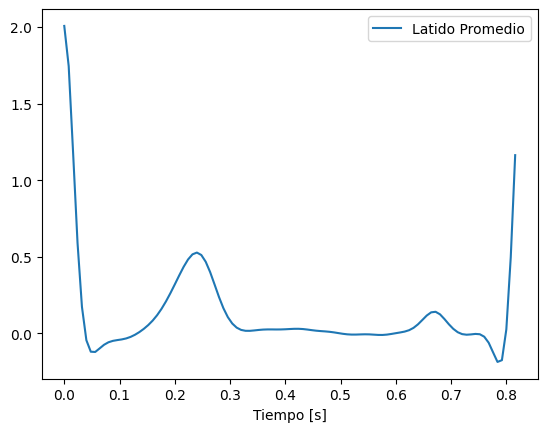

In [14]:
#Para el cálculo del latido promedio se utilizan las detectadas efectuadas anteriormente y se pasan las ubicaciones de las mismas
#Cálculo del Latido Promedio
Lat_Prom,t_Prom=FUN_PromLatidos(ECG_CH_f, ECG_RR_Pos, t)
plt.plot(t_Prom,Lat_Prom)
plt.xlabel('Tiempo [s]')
plt.legend(['Latido Promedio'])